In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import tensorflow as tf
import datetime
from dateutil.relativedelta import relativedelta

from simulation_engine.common.types import SimulationPortfolioWeights

tf.config.set_visible_devices([], 'GPU')


2025-11-18 15:14:11.636164: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
from services import SimulationService
from schemas import AdviserConfig, Profile, RecurringCashFlow
from simulation_engine_tf.common.types import CashFlow, SimulationPortfolioWeights, AssetCosts, ExpectedReturns
from simulation_engine_tf.commands import RunSimulationCommandTF
from simulation_engine_tf.common.enums import SimulationType, SimulationStepType, InterpolationMethod


n_sims = 10000
end_step = 60
initial_wealth = 100000


weights = [
    SimulationPortfolioWeights(step=0, stocks=0.9, bonds=0.08),
    SimulationPortfolioWeights(step=40, stocks=0.3, bonds=0.68)
]

cash_flows = [
    CashFlow(step=0, value=25000),
    CashFlow(step=30, value=-40000)

]


/Users/oliver/Repos/AdviceTools/.venv/lib/python3.12/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'validate_by_name'
* 'validate_all' has been renamed to 'validate_default'
  warnings.warn(message, UserWarning)
/Users/oliver/Repos/AdviceTools/.venv/lib/python3.12/site-packages/pydantic/_internal/_config.py:383: UserWarning: Valid config keys have changed in V2:
* 'allow_population_by_field_name' has been renamed to 'validate_by_name'
* 'validate_all' has been renamed to 'validate_default'
  warnings.warn(message, UserWarning)


In [ ]:

def tf_sigmoid(x, steepness=10.0):
    return 1.0 / (1.0 + tf.exp(-steepness * x))

def build_tf_simulation_overrides(allocations_tf, cash_flows, total_steps):
    allocations_tf = tf.cast(allocations_tf, tf.float64)
    stocks = tf.clip_by_value(allocations_tf, 0.0, 1.0)
    bonds = tf.clip_by_value(1.0 - stocks, 0.0, 1.0)
    cash = tf.zeros_like(stocks)
    weights_tensor = tf.stack([stocks, bonds, cash], axis=1)

    cashflow_arr = np.zeros(total_steps, dtype=np.float64)
    for cf in cash_flows:
        step_idx = int(np.clip(cf.step, 0, total_steps - 1))
        cashflow_arr[step_idx] += float(cf.value)
    cashflows_tensor = tf.convert_to_tensor(cashflow_arr, dtype=tf.float64)

    transactions_tensor = tf.zeros_like(cashflows_tensor)
    time_steps_tensor = tf.range(0, total_steps + 1, dtype=tf.float64)

    return weights_tensor, cashflows_tensor, transactions_tensor, time_steps_tensor


def tf_negative_sigmoid_objective(
        cash_flows,
        allocations_tf,
        target_wealth=0.0,
        steepness=20.0,
        scale_factor=100000.0):

    (
        weights_tensor,
        cashflows_tensor,
        transactions_tensor,
        time_steps_tensor,
    ) = build_tf_simulation_overrides(allocations_tf, cash_flows, end_step)

    command = RunSimulationCommandTF(
        number_of_simulations=n_sims,
        end_step=end_step,
        weights=weights,
        savings_rates=cash_flows,
        oneoff_transactions=[],
        inflation=0.02,
        initial_wealth=initial_wealth,
        percentiles=[5, 25, 50, 75, 95],
        simulation_type=SimulationType.CHOLESKY,
        step_size=SimulationStepType.ANNUAL,
        weights_interpolation=InterpolationMethod.FFILL,
        savings_rate_interpolation=InterpolationMethod.FFILL,
        asset_costs=AssetCosts(),
        asset_returns=ExpectedReturns(),
        weights_tensor=weights_tensor,
        cashflows_tensor=cashflows_tensor,
        transactions_tensor=transactions_tensor,
        time_steps_tensor=time_steps_tensor,
    )

    simulation_paths = command.handle_tf()

    target_tensor = tf.cast(target_wealth, dtype=simulation_paths.dtype)
    scale = tf.cast(scale_factor, dtype=simulation_paths.dtype)


    wealth_diffs = (simulation_paths - target_tensor) / scale
    sigmoid_transformed = -tf_sigmoid(wealth_diffs, steepness=steepness)
    objective = tf.reduce_sum(sigmoid_transformed)

    return objective


In [ ]:
def optimize_with_tensorflow(initial_allocations,
                           cash_flows,
                           target_wealth=0.0,
                           steepness=10.0,
                           scale_factor=10000.0,
                           max_iterations=100,
                           learning_rate=0.01):

    allocations = tf.Variable(initial_allocations, dtype=tf.float32, trainable=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    objective_history = []
    
    def train_step(allocations_tf):
        with tf.GradientTape() as tape:
            objective_value = tf_negative_sigmoid_objective(
                cash_flows,
                allocations_tf, 
                target_wealth,
                steepness,
                scale_factor
            )

        gradients = tape.gradient(objective_value, allocations_tf)
        optimizer.apply_gradients([(gradients, allocations_tf)])
        return objective_value

    for iteration in range(max_iterations):

        objective_value = train_step(allocations)
        allocations.assign(tf.clip_by_value(allocations, 0.0, 1.0))
        objective_history.append(float(objective_value))

    return allocations.numpy(), objective_history

initial_allocations = np.linspace(0.9, 0.3, end_step)

optimized_allocations, history = optimize_with_tensorflow(
    initial_allocations,
    cash_flows,
    target_wealth=0,
    steepness=3.0,
    scale_factor=500000,
    max_iterations=100,
    learning_rate=0.001
)

print(f"Initial objective: {history[0]:.2f}")
print(f"Final objective: {history[-1]:.2f}")
print(f"Improvement: {history[0] - history[-1]:.2f}")


Starting optimization with TensorFlow and real SimulationService...


/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:194: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


total_objective:  tf.Tensor(-572665.5629005404, shape=(), dtype=float64)


/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:194: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


total_objective:  tf.Tensor(-572824.7594038153, shape=(), dtype=float64)


...

total_objective:  tf.Tensor(-573395.2016445862, shape=(), dtype=float64)


/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:194: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


total_objective:  tf.Tensor(-573425.4080814895, shape=(), dtype=float64)


/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:89: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base_sim_data["transactions"] = base_sim_data["transactions"].fillna(0)
/Users/oliver/Repos/AdviceTools/simulation_engine_tf/commands.py:194: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  exp_return['Expected Return'] = exp_return['overrides'].combine_first(exp_return['Expected Return'])


total_objective:  tf.Tensor(-573521.5292236364, shape=(), dtype=float64)

Optimization complete!
Initial objective: -572665.56
Final objective: -573521.53
Improvement: 855.97


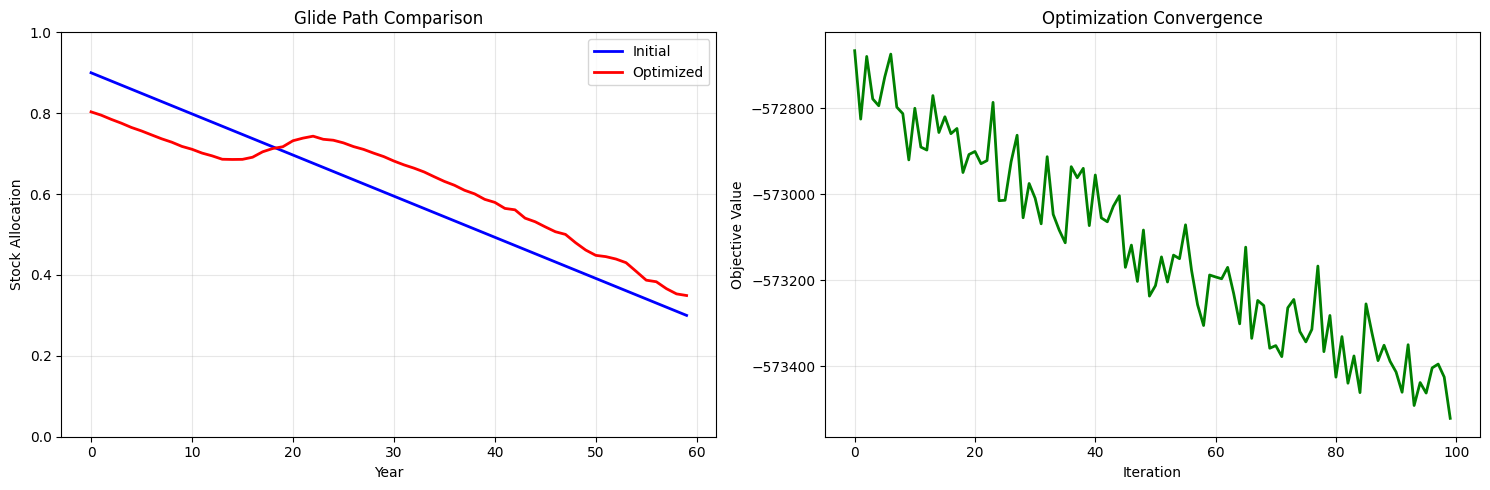

In [ ]:
# Visualise results


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

years = np.arange(len(initial_allocations))
ax1.plot(years, initial_allocations, 'b-', label='Initial', linewidth=2)
ax1.plot(years, optimized_allocations, 'r-', label='Optimized', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Stock Allocation')
ax1.set_title('Glide Path Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.plot(history, 'g-', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Objective Value')
ax2.set_title('Optimization Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

